In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [2]:
# Loadng the data
df=pd.read_csv("country_wise_latest.csv")
df.head()


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [3]:
#Handle missing data
print(df.isnull().sum())

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64


In [4]:
country_name = "Kenya"
country_data = df[df['Country/Region'] == country_name].copy()

In [5]:
y_active = country_data['Active'].values
y_removed = (country_data['Recovered'] + country_data['Deaths']).values
days = np.arange(len(y_active))

In [6]:
N = 53_330_978  # Total population of Kenya

In [7]:
def sir_equations(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

In [9]:
from scipy.integrate import odeint
def run_simulation(beta, gamma, days, N, I0, R0):
    S0 = N - I0 - R0
    y0 = [S0, I0, R0]
    # Numerical Integration of the ODEs
    sol = odeint(sir_equations, y0, days, args=(N, beta, gamma))
    return sol

In [11]:
def objective_function(params, days, y_active, N):
    beta, gamma = params
    # Initial conditions from your dataset's first day
    I0 = y_active[0]
    R0 = y_removed[0]

    prediction = run_simulation(beta, gamma, days, N, I0, R0)
    # We calculate the error between model 'I' and real 'Active'
    # Mean Squared Error (MSE)
    return np.sqrt(np.mean((prediction[:, 1] - y_active)**2))

In [12]:
from scipy.optimize import minimize
# Initial guess for Beta and Gamma
initial_guess = [0.2, 0.1]

# Minimize the error to find the real Beta and Gamma for this country
result = minimize(objective_function, initial_guess, args=(days, y_active, N),
                  bounds=[(0.001, 1), (0.001, 1)])

best_beta, best_gamma = result.x

--- Results for Kenya ---
Optimal Beta (Spread Rate): 0.2000
Optimal Gamma (Recovery Rate): 0.1000
Calculated R0: 2.00


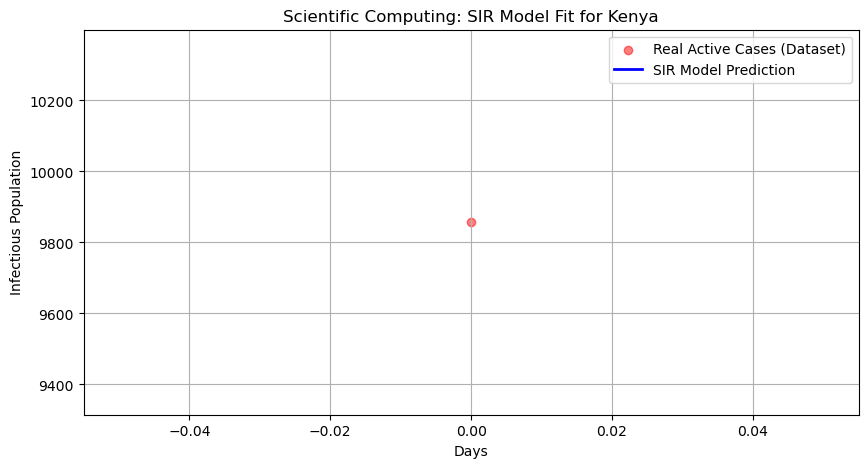

In [13]:
print(f"--- Results for {country_name} ---")
print(f"Optimal Beta (Spread Rate): {best_beta:.4f}")
print(f"Optimal Gamma (Recovery Rate): {best_gamma:.4f}")
print(f"Calculated R0: {best_beta/best_gamma:.2f}")

# Generate the final "Best Fit" curve
final_fit = run_simulation(best_beta, best_gamma, days, N, y_active[0], y_removed[0])

plt.figure(figsize=(10, 5))
plt.scatter(days, y_active, label="Real Active Cases (Dataset)", color='red', alpha=0.5)
plt.plot(days, final_fit[:, 1], label="SIR Model Prediction", color='blue', lw=2)
plt.xlabel("Days")
plt.ylabel("Infectious Population")
plt.title(f"Scientific Computing: SIR Model Fit for {country_name}")
plt.legend()
plt.grid(True)
plt.show()